In [ ]:
from google.colab import files
uploaded = files.upload()

Saving train.csv to train (1).csv


##READ DATA

In [ ]:
import pandas as pd
file_name = list(uploaded.keys())[0]
data=pd.read_csv(file_name)
print(data.head())

   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
1       2  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
2       3  CA-2017-138688  12/06/2017  16/06/2017    Second Class    DV-13045   
3       4  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   
4       5  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   

     Customer Name    Segment        Country             City       State  \
0      Claire Gute   Consumer  United States        Henderson    Kentucky   
1      Claire Gute   Consumer  United States        Henderson    Kentucky   
2  Darrin Van Huff  Corporate  United States      Los Angeles  California   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   

   Postal Code Region       Product ID         Cat

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [ ]:
data.nunique()

,0
Row ID,9800
Order ID,4922
Order Date,1230
Ship Date,1326
Ship Mode,4
Customer ID,793
Customer Name,793
Segment,3
Country,1
City,529


In [ ]:
data.set_index(data["Row ID"],inplace=True)
data.drop(columns=["Row ID","Country","Postal Code","Product ID","Customer ID"], axis=1, inplace=True)

### 🟩 **Categorical**
- **Nominal:** `OrderID`, `Order Date`, `Ship Date`,`Customer Name`, `City`, `State`, `Region`, `Category`, `Sub Category`, `Product Name`
- **Ordinal:** `Ship Mode`, `Segment`

### 🔢 **Numerical**
-  `Sales`



In [ ]:
data["Order Date"] = pd.to_datetime(data["Order Date"], dayfirst=True)
data["Ship Date"] = pd.to_datetime(data["Ship Date"], dayfirst=True)
data["Year"]=data["Order Date"].dt.year
data["Month"]=data["Order Date"].dt.month
def apply_season(month):
  if month in [3,4,5]:
    return "Spring"
  elif month in [6,7,8]:
    return "Summer"
  elif month in [9,10,11]:
    return "Fall"
  else:
    return "Winter"
data["Season"]=data["Month"].apply(apply_season)
print(data.info())


<class 'pandas.core.frame.DataFrame'>
Index: 9800 entries, 1 to 9800
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order ID       9800 non-null   object        
 1   Order Date     9800 non-null   datetime64[ns]
 2   Ship Date      9800 non-null   datetime64[ns]
 3   Ship Mode      9800 non-null   object        
 4   Customer Name  9800 non-null   object        
 5   Segment        9800 non-null   object        
 6   City           9800 non-null   object        
 7   State          9800 non-null   object        
 8   Region         9800 non-null   object        
 9   Category       9800 non-null   object        
 10  Sub-Category   9800 non-null   object        
 11  Product Name   9800 non-null   object        
 12  Sales          9800 non-null   float64       
 13  Year           9800 non-null   int32         
 14  Month          9800 non-null   int32         
 15  Season         9800 non-nu

In [ ]:
converted_factures=["Order ID", "Ship Mode", "Segment", "City", "State", "Region", "Category", "Sub-Category", "Product Name", "Year", "Month", "Season"]
for col in converted_factures:
  data[col]=data[col].astype("category")
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9800 entries, 1 to 9800
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order ID       9800 non-null   category      
 1   Order Date     9800 non-null   datetime64[ns]
 2   Ship Date      9800 non-null   datetime64[ns]
 3   Ship Mode      9800 non-null   category      
 4   Customer Name  9800 non-null   object        
 5   Segment        9800 non-null   category      
 6   City           9800 non-null   category      
 7   State          9800 non-null   category      
 8   Region         9800 non-null   category      
 9   Category       9800 non-null   category      
 10  Sub-Category   9800 non-null   category      
 11  Product Name   9800 non-null   category      
 12  Sales          9800 non-null   float64       
 13  Year           9800 non-null   category      
 14  Month          9800 non-null   category      
 15  Season         9800 non-nu

In [ ]:
data["Sales"].describe()

,Sales
count,9800.000000
mean,230.769059
std,626.651875
min,0.444000
25%,17.248000
50%,54.490000
75%,210.605000
max,22638.480000


## Distribution of category features

In [ ]:
data.describe(include=['category'])

,Order ID,Ship Mode,Segment,City,State,Region,Category,Sub-Category,Product Name,Year,Month,Season
count,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800
unique,4922,4,3,529,49,4,3,17,1849,4,12,4
top,CA-2018-100111,Standard Class,Consumer,New York City,California,West,Office Supplies,Binders,Staple envelope,2018,11,Fall
freq,14,5859,5101,891,1946,3140,5909,1492,47,3258,1449,3612


In [ ]:
data.describe(include=['object'])

,Customer Name
count,9800
unique,793
top,William Brown
freq,35


### Kết quả phân tích dữ liệu (EDA Summary)

#### 1. Đơn hàng
- **Đơn hàng đặt mua nhiều món hàng nhất:** `CA-2018-100111`

#### 2. Vận chuyển
- **Ship Mode được sử dụng/ưu tiên nhiều nhất:** `Standard Class`

#### 3. Khách hàng
- **Khách hàng thường xuyên nhất:** `William Brown`
- **Phân khúc khách hàng:** `Consumer`

#### 4. Địa lý
- **Thành phố (City):** `New York City`  
- **Bang (State):** `California`  
- **Vùng (Region):** `West`

#### 5. Sản phẩm
- **Sub-category được đặt nhiều nhất:** `Binder`  
- **Sản phẩm được mua nhiều nhất:** `Staple Envelope`


In [ ]:
import seaborn as sns

##Segment

/tmp/ipython-input-43858000.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment_sales = data.groupby("Segment", as_index=False)["Sales"].sum()
/tmp/ipython-input-43858000.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=segment_sales, x="Segment", y="Sales", palette="Blues_d")


<Axes: xlabel='Segment', ylabel='Sales'>

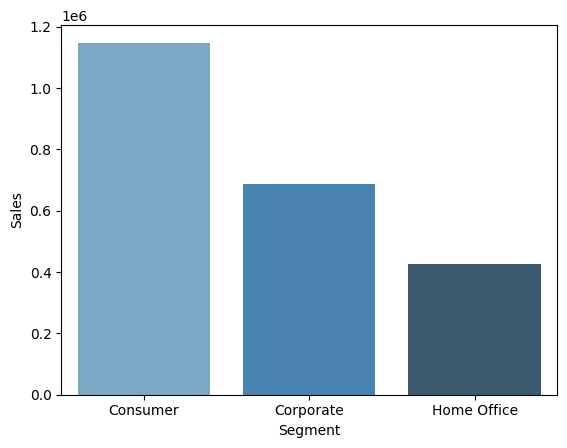

In [ ]:
segment_sales = data.groupby("Segment", as_index=False)["Sales"].sum()
sns.barplot(data=segment_sales, x="Segment", y="Sales", palette="Blues_d")

**Consumer** đang cho thấy sự vượt trội so với 2 phần còn lại vậy nên độ ưu tiên sẽ đổ dồn cho Consumer.

##Ship Mode

/tmp/ipython-input-590664587.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ShipMode_sales = data.groupby("Ship Mode", as_index=False)["Sales"].sum()
/tmp/ipython-input-590664587.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ShipMode_sales, x="Ship Mode", y="Sales", palette="Blues_d")


<Axes: xlabel='Ship Mode', ylabel='Sales'>

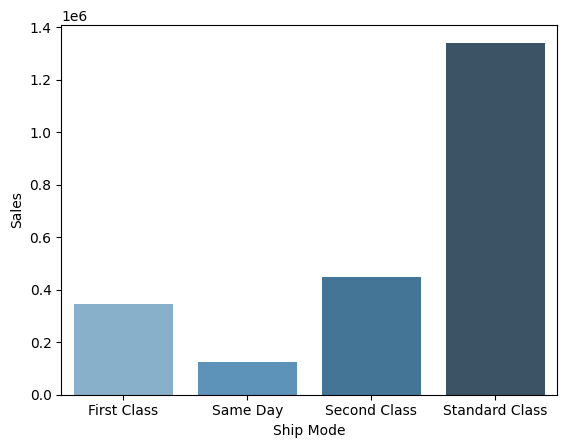

In [ ]:
ShipMode_sales = data.groupby("Ship Mode", as_index=False)["Sales"].sum()
sns.barplot(data=ShipMode_sales, x="Ship Mode", y="Sales", palette="Blues_d")

**Standard > Second > first> same day**

##Region

/tmp/ipython-input-1705381133.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  region_sales = data.groupby("Region", as_index=False)["Sales"].sum()
/tmp/ipython-input-1705381133.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=region_sales, x="Region", y="Sales", palette="Blues_d")


<Axes: xlabel='Region', ylabel='Sales'>

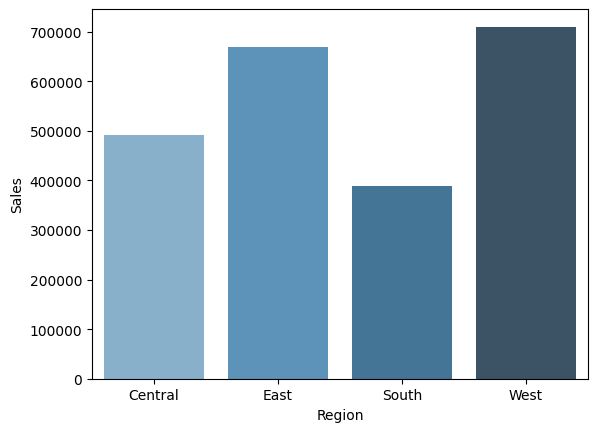

In [ ]:
region_sales = data.groupby("Region", as_index=False)["Sales"].sum()
sns.barplot(data=region_sales, x="Region", y="Sales", palette="Blues_d")

- **West** và **East** chiếm đa số doanh thu.  
- **Central** có doanh thu ở mức trung bình.  
- **South** đạt doanh thu thấp nhất.


## Category

/tmp/ipython-input-4181990519.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  Category_sales = data.groupby("Category", as_index=False)["Sales"].sum()
/tmp/ipython-input-4181990519.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=Category_sales, x="Category", y="Sales", palette="Blues_d")


<Axes: xlabel='Category', ylabel='Sales'>

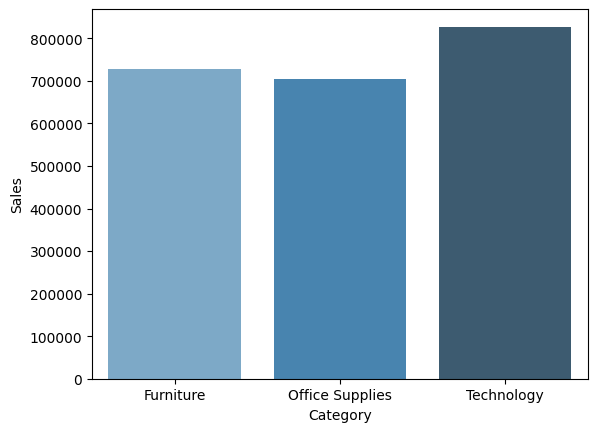

In [ ]:
Category_sales = data.groupby("Category", as_index=False)["Sales"].sum()
sns.barplot(data=Category_sales, x="Category", y="Sales", palette="Blues_d")

Đều ở cả 3 doanh mục

##Sub-category

In [ ]:
import matplotlib.pyplot as plt

/tmp/ipython-input-4112292991.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  subcat_sales = data.groupby("Sub-Category")["Sales"].sum().sort_values(ascending=True)
/tmp/ipython-input-4112292991.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=subcat_sales.index, x=subcat_sales.values, palette="Blues_d",order=subcat_sales.index)


<Axes: ylabel='Sub-Category'>

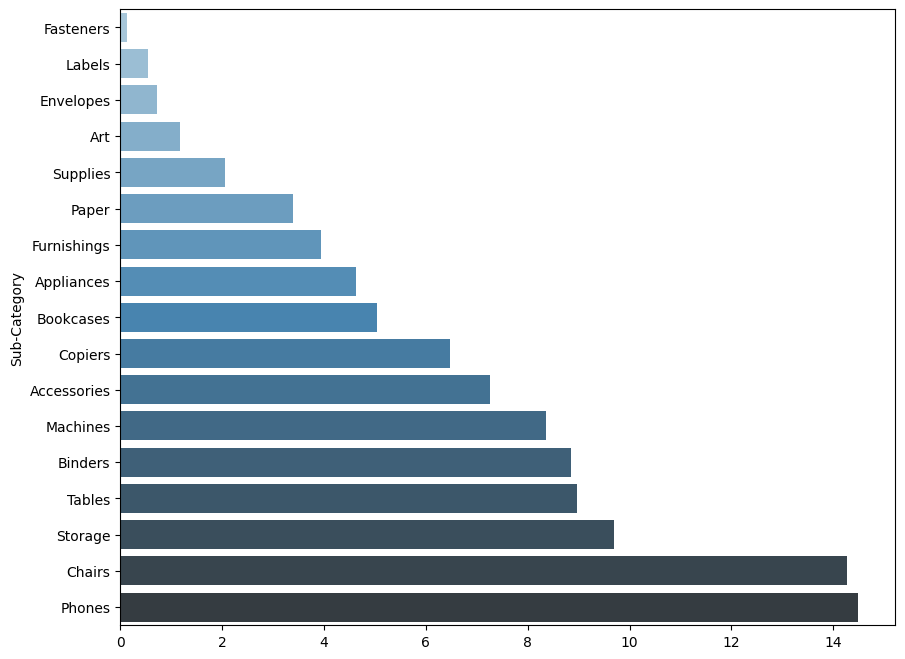

In [ ]:
subcat_sales = data.groupby("Sub-Category")["Sales"].sum().sort_values(ascending=True)
total_sales=subcat_sales.sum()
subcat_sales=subcat_sales/total_sales*100
plt.figure(figsize=(10, 8))
sns.barplot(y=subcat_sales.index, x=subcat_sales.values, palette="Blues_d",order=subcat_sales.index)

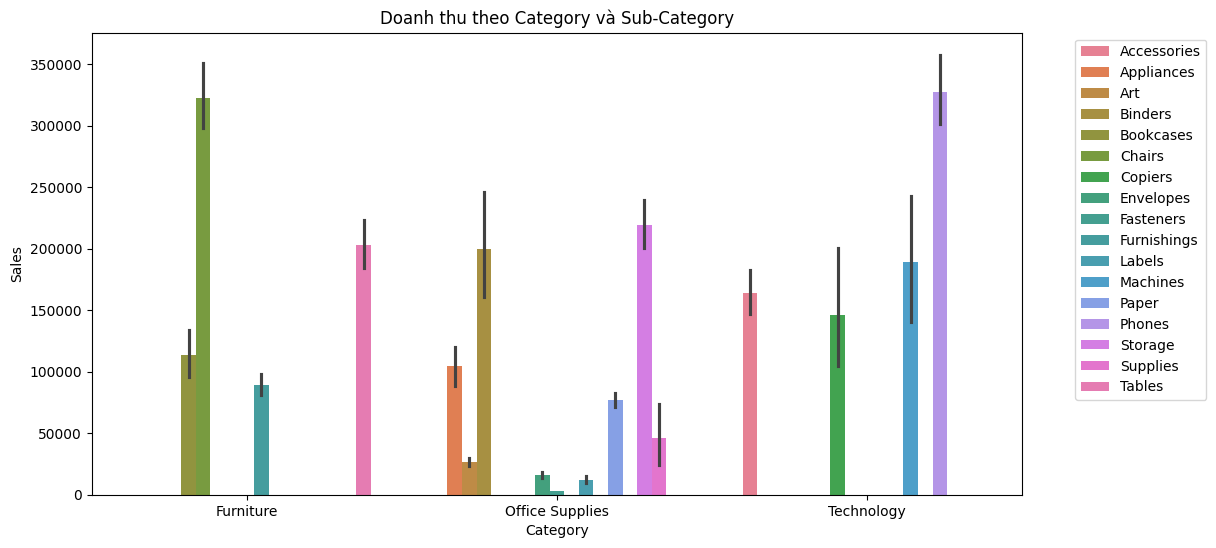

In [ ]:
plt.figure(figsize=(12,6))
sns.barplot(
    data=data,
    x="Category",
    y="Sales",
    hue="Sub-Category",
    estimator="sum"
)
plt.title("Doanh thu theo Category và Sub-Category")
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

### Nhận xét biểu đồ: Doanh thu theo Category và Sub-Category

- Ba nhóm **Category (Furniture, Office Supplies, Technology)** có tổng doanh thu khá tương đương nhau.  
- Tuy nhiên, khi xét chi tiết theo **Sub-Category**, sự khác biệt thể hiện rất rõ:  
  - **Furniture:** Mặt hàng **Chairs** chiếm doanh thu cao nhất, vượt xa các nhóm khác như Tables hay Bookcases.  
  - **Office Supplies:** Doanh thu phân bố khá đồng đều, nhưng **Binders** và **Storage** nổi bật hơn so với Labels hay Envelopes.  
  - **Technology:** **Phones** là mặt hàng chủ lực, đóng góp doanh thu cao nhất toàn bộ, theo sau là Machines và Copiers.  
- Kết luận: Dù ba nhóm Category có tổng doanh thu tương tự nhau, nhưng trong từng nhóm, chỉ một vài **Sub-Category chủ lực** chiếm phần lớn doanh thu. Việc tập trung vào các sản phẩm này sẽ giúp tối ưu hiệu quả kinh doanh.


## City and region

/tmp/ipython-input-158979014.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  city_region_sales = data.groupby(["Region", "City"])["Sales"].sum().reset_index()
/tmp/ipython-input-158979014.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top_city_region = city_region_sales.groupby("Region", group_keys=False).apply(lambda x: x.nlargest(5, "Sales"))
/tmp/ipython-input-158979014.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups

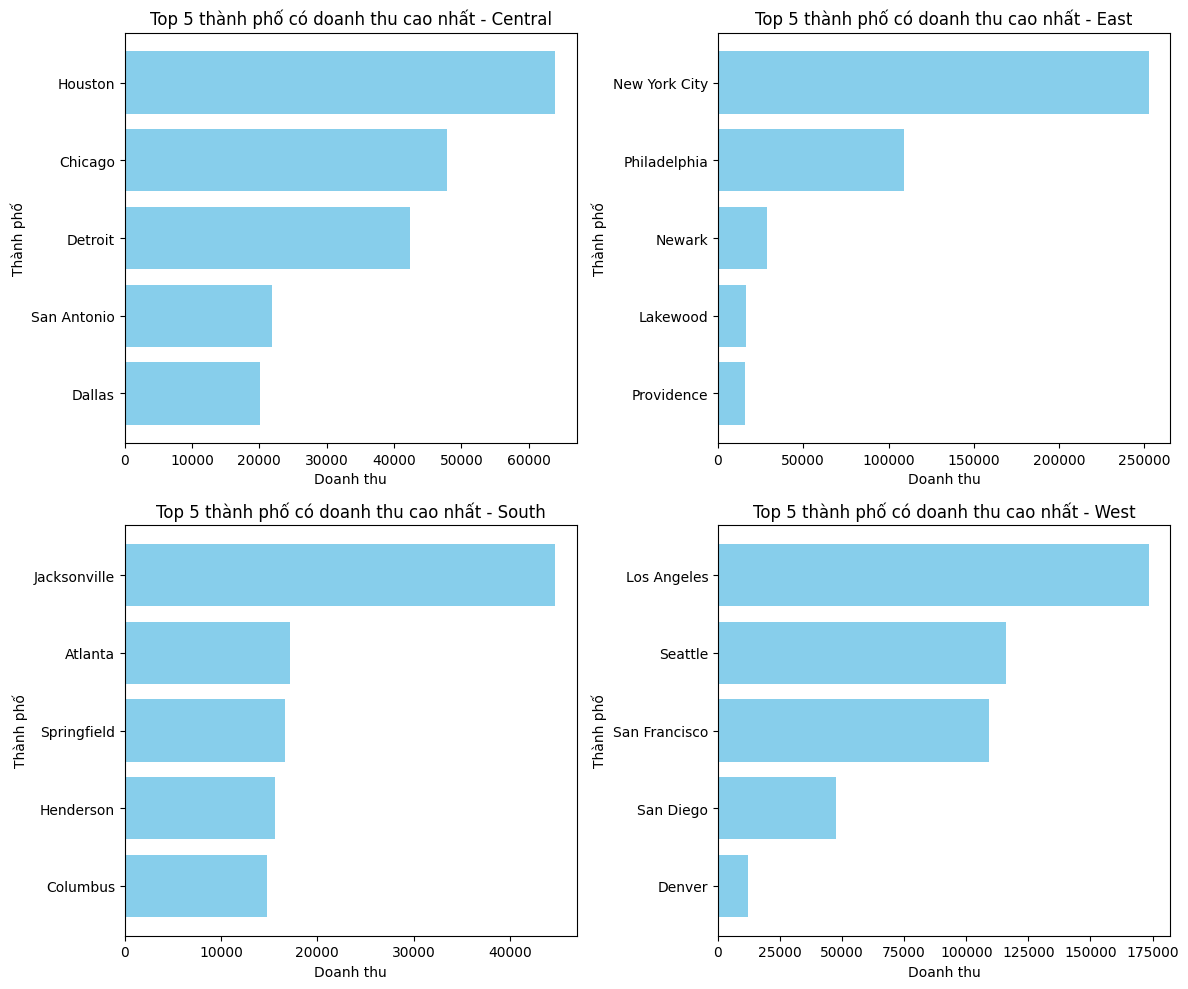

In [ ]:

city_region_sales = data.groupby(["Region", "City"])["Sales"].sum().reset_index()

top_city_region = city_region_sales.groupby("Region", group_keys=False).apply(lambda x: x.nlargest(5, "Sales"))

regions = ["Central","East","South","West"]

n_rows, n_cols = 2, 2
fig, ax = plt.subplots(n_rows, n_cols, figsize=(n_cols*6, n_rows*5))

for r in range(n_rows):
    for c in range(n_cols):
        i = r * n_cols + c
        if i < len(regions):
            region = regions[i]
            subset = top_city_region[top_city_region["Region"] == region]

            ax_i = ax[r, c]
            ax_i.barh(subset["City"], subset["Sales"], color='skyblue')
            ax_i.set_title(f"Top 5 thành phố có doanh thu cao nhất - {region}")
            ax_i.set_xlabel("Doanh thu")
            ax_i.set_ylabel("Thành phố")
            ax_i.invert_yaxis()

plt.tight_layout()
plt.show()


In [ ]:
top5_sum_region = top_city_region.groupby("Region")["Sales"].sum().reset_index()

print(top5_sum_region)

    Region       Sales
0  Central  196194.696
1     East  422332.419
2    South  109001.933
3     West  458287.445


/tmp/ipython-input-3019227216.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top5_sum_region = top_city_region.groupby("Region")["Sales"].sum().reset_index()


Biểu đồ và số liệu thể hiện **khả năng mua hàng ở các khu vực East và West rất cao**.  

- **Khu vực East**: doanh thu tập trung chủ yếu tại **New York City**, vượt trội so với các thành phố khác.  
  Từ **top 3 trở xuống**, doanh thu chỉ dao động khoảng **100.000 đô**, cho thấy sự **tập trung cao** vào một thành phố chính.  

- **Khu vực West**: có sự **phân bổ doanh thu đồng đều hơn**, khi **cả 3 thành phố dẫn đầu đều vượt trên 100.000 đô**.  
  Điều này cho thấy sức mua tại khu vực West được **phân tán rộng hơn** thay vì tập trung vào một thành phố duy nhất.


## Season

/tmp/ipython-input-3315190499.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  Season_sales = data.groupby("Season", as_index=False)["Sales"].sum()
/tmp/ipython-input-3315190499.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=Season_sales, x="Season", y="Sales", palette="Blues_d")


<Axes: xlabel='Season', ylabel='Sales'>

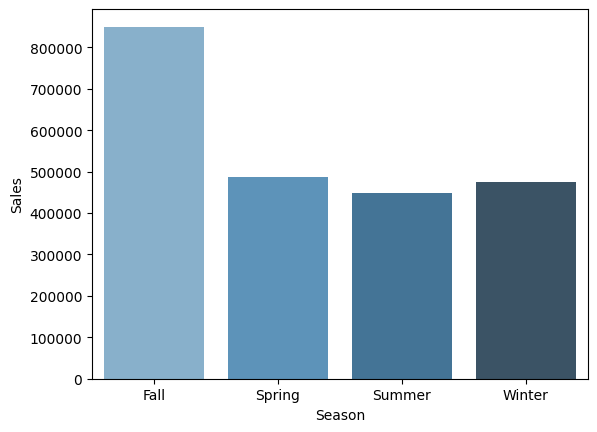

In [ ]:
Season_sales = data.groupby("Season", as_index=False)["Sales"].sum()
sns.barplot(data=Season_sales, x="Season", y="Sales", palette="Blues_d")

Mùa mua bán năng động nhất là mùa thu cụ thể vào tháng 9,10,11

In [ ]:
data['Order_Sales_Sum'] = data.groupby('Order ID')['Sales'].transform('sum')
data['Order_Sales_Sum'].describe()

/tmp/ipython-input-308454644.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data['Order_Sales_Sum'] = data.groupby('Order ID')['Sales'].transform('sum')


,Order_Sales_Sum
count,9800.000000
mean,714.068896
std,1323.133361
min,0.556000
25%,85.503000
50%,318.293000
75%,829.932500
max,23661.228000


In [ ]:
Order_Category=["Low", "Medium_Low", "Medium_High", "High"]
quartile_data=pd.qcut(data['Order_Sales_Sum'],4,labels=Order_Category,duplicates='drop')
data["Order_Sales_Sum"]=quartile_data


In [ ]:
print(data.head())

              Order ID Order Date  Ship Date       Ship Mode    Customer Name  \
Row ID                                                                          
1       CA-2017-152156 2017-11-08 2017-11-11    Second Class      Claire Gute   
2       CA-2017-152156 2017-11-08 2017-11-11    Second Class      Claire Gute   
3       CA-2017-138688 2017-06-12 2017-06-16    Second Class  Darrin Van Huff   
4       US-2016-108966 2016-10-11 2016-10-18  Standard Class   Sean O'Donnell   
5       US-2016-108966 2016-10-11 2016-10-18  Standard Class   Sean O'Donnell   

          Segment             City       State Region         Category  \
Row ID                                                                   
1        Consumer        Henderson    Kentucky  South        Furniture   
2        Consumer        Henderson    Kentucky  South        Furniture   
3       Corporate      Los Angeles  California   West  Office Supplies   
4        Consumer  Fort Lauderdale     Florida  South        F

In [ ]:
data.drop(columns=["Order Date","Ship Date", "Month"], axis=1, inplace=True)
print(data.info())

<class 'pandas.core.frame.DataFrame'>
Index: 9800 entries, 1 to 9800
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   Order ID         9800 non-null   category
 1   Ship Mode        9800 non-null   category
 2   Customer Name    9800 non-null   object  
 3   Segment          9800 non-null   category
 4   City             9800 non-null   category
 5   State            9800 non-null   category
 6   Region           9800 non-null   category
 7   Category         9800 non-null   category
 8   Sub-Category     9800 non-null   category
 9   Product Name     9800 non-null   category
 10  Sales            9800 non-null   float64 
 11  Year             9800 non-null   category
 12  Season           9800 non-null   category
 13  Order_Sales_Sum  9800 non-null   category
dtypes: category(12), float64(1), object(1)
memory usage: 643.3+ KB
None


In [ ]:
from sklearn.preprocessing import LabelEncoder,OneHotEncoder,TargetEncoder,OrdinalEncoder
data["customer_total_sales"] = data.groupby("Customer Name")["Sales"].transform("sum")
data["customer_order_count"] = data.groupby("Customer Name")["Order ID"].transform("nunique")
data["customer_avg_sales"]=data["customer_total_sales"]/data["customer_order_count"]


In [ ]:
Label_customer=["Not-noticable","Normal","Noticable","VIP"]
data["customer_avg_sales"]=pd.qcut(data["customer_avg_sales"],4,labels=Label_customer,duplicates='drop')


In [ ]:
data.drop(columns=["customer_total_sales","customer_order_count","Order ID","Customer Name"], axis=1, inplace=True)


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9800 entries, 1 to 9800
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   Ship Mode           9800 non-null   category
 1   Segment             9800 non-null   category
 2   City                9800 non-null   category
 3   State               9800 non-null   category
 4   Region              9800 non-null   category
 5   Category            9800 non-null   category
 6   Sub-Category        9800 non-null   category
 7   Product Name        9800 non-null   category
 8   Sales               9800 non-null   float64 
 9   Year                9800 non-null   category
 10  Season              9800 non-null   category
 11  Order_Sales_Sum     9800 non-null   category
 12  customer_avg_sales  9800 non-null   category
dtypes: category(12), float64(1)
memory usage: 389.9 KB


In [ ]:
ordinal_encode=["Season","Order_sales_sum","customer_avg_sales","Segment"]
order_sales_sum_order=["Low", "Medium_Low", "Medium_High", "High"]

customer_avg_sales_order=["Not-noticable","Normal","Noticable","VIP"]
encoder = OrdinalEncoder(
    categories=[order_sales_sum_order,customer_avg_sales_order],
    dtype=float
)
data[["Order_Sales_Sum","customer_avg_sales"]] = encoder.fit_transform(data[["Order_Sales_Sum","customer_avg_sales"]])

In [ ]:
basic_encode=["Ship Mode","Category","Segment","Region","Season"]

data = pd.get_dummies(data, columns=basic_encode, dtype=float)

In [ ]:
freq_cols = ["City", "State", "Sub-Category", "Product Name"]
for col in freq_cols:
    freq = data[col].value_counts(normalize=True)
    data[col + "_freq"] = data[col].map(freq)
    data.drop(columns=[col], inplace=True)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9800 entries, 1 to 9800
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   Sales                     9800 non-null   float64 
 1   Year                      9800 non-null   category
 2   Order_Sales_Sum           9800 non-null   float64 
 3   customer_avg_sales        9800 non-null   float64 
 4   Ship Mode_First Class     9800 non-null   float64 
 5   Ship Mode_Same Day        9800 non-null   float64 
 6   Ship Mode_Second Class    9800 non-null   float64 
 7   Ship Mode_Standard Class  9800 non-null   float64 
 8   Category_Furniture        9800 non-null   float64 
 9   Category_Office Supplies  9800 non-null   float64 
 10  Category_Technology       9800 non-null   float64 
 11  Segment_Consumer          9800 non-null   float64 
 12  Segment_Corporate         9800 non-null   float64 
 13  Segment_Home Office       9800 non-null   float64 
 1

In [ ]:
from sklearn.model_selection import train_test_split
train_data_unused = data[data["Year"] != 2018]
train_data, valid_data = train_test_split(train_data_unused, test_size=0.25, random_state=42)
test_data  = data[data["Year"] == 2018]
train_data.drop(columns=["Year"], inplace=True)
valid_data.drop(columns=["Year"], inplace=True)
test_data.drop(columns=["Year"], inplace=True)
train_data_expected=train_data["Sales"]
train_data_feature=train_data.drop(columns=["Sales"])
valid_data_expected=valid_data["Sales"]
valid_data_feature=valid_data.drop(columns=["Sales"])
test_data_expected=test_data["Sales"]
test_data_feature=test_data.drop(columns=["Sales"])
print(train_data.shape)
print(valid_data.shape)
print(test_data.shape)


(4906, 25)
(1636, 25)
(3258, 25)


/tmp/ipython-input-3818031099.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_data.drop(columns=["Year"], inplace=True)


In [ ]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestRegressor

model=RandomForestRegressor()
rfe=RFE(model,n_features_to_select=5)
rfe.fit(train_data_feature,train_data_expected)

selected_features = train_data_feature.columns[rfe.support_]
print(selected_features)

KeyboardInterrupt: 

In [ ]:
model_1 = RandomForestRegressor(random_state=42)
model.fit(train_data_feature,train_data_expected)

importances = model.feature_importances_

feat_imp = pd.DataFrame({
    "Feature": train_data_feature.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(feat_imp)

In [ ]:
import numpy as np

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score,mean_absolute_percentage_error
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf.fit(train_data_feature,train_data_expected)
rf_pred = rf.predict(test_data_feature)
print("MAE:", mean_absolute_error(test_data_expected, rf_pred))
print("RMSE:", np.sqrt(mean_squared_error(test_data_expected, rf_pred)))
print("R² Score:", r2_score(test_data_expected, rf_pred))
print("MAPE:", mean_absolute_percentage_error(test_data_expected, rf_pred))

In [ ]:
train_data_feature = train_data_feature.astype('float64')
test_data_feature = test_data_feature.astype('float64')
valid_data_feature = valid_data_feature.astype('float64')

In [ ]:
print(train_data_feature.dtypes)
print(test_data_feature.dtypes)
print(valid_data_feature.dtypes)

Order_Sales_Sum             float64
customer_avg_sales          float64
Ship Mode_First Class       float64
Ship Mode_Same Day          float64
Ship Mode_Second Class      float64
Ship Mode_Standard Class    float64
Category_Furniture          float64
Category_Office Supplies    float64
Category_Technology         float64
Segment_Consumer            float64
Segment_Corporate           float64
Segment_Home Office         float64
Region_Central              float64
Region_East                 float64
Region_South                float64
Region_West                 float64
Season_Fall                 float64
Season_Spring               float64
Season_Summer               float64
Season_Winter               float64
City_freq                   float64
State_freq                  float64
Sub-Category_freq           float64
Product Name_freq           float64
dtype: object
Order_Sales_Sum             float64
customer_avg_sales          float64
Ship Mode_First Class       float64
Ship Mode_Same

In [ ]:
from google.colab import files

train_data.to_csv("train_data.csv", index=False)
valid_data.to_csv("valid_data.csv", index=False)
test_data.to_csv("test_data.csv", index=False)

files.download("train_data.csv")
files.download("valid_data.csv")
files.download("test_data.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from xgboost import XGBRegressor
xgb_model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=4,
    random_state=42,
    eval_metric='mape'
)
xgb_model.fit(
    train_data_feature, train_data_expected,
    eval_set=[(train_data_feature, train_data_expected), (valid_data_feature, valid_data_expected)]
)
xgb_pred = xgb_model.predict(test_data_feature)
print("MAE:", mean_absolute_error(test_data_expected, xgb_pred))
print("RMSE:", np.sqrt(mean_squared_error(test_data_expected, xgb_pred)))
print("R² Score:", r2_score(test_data_expected, xgb_pred))
print("MAPE:", mean_absolute_percentage_error(test_data_expected, xgb_pred))